# Day 08. Exercise 05
# Clustering

## 0. Imports

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [33]:
df = pd.read_csv('../../datasets/regression.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   uid          29 non-null     object 
 1   num_commits  29 non-null     int64  
 2   pageviews    29 non-null     float64
 3   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 1.0+ KB


In [34]:
df.drop(columns='pageviews', inplace=True)
df.head()

,uid,num_commits,AVG(diff)
0,user_1,62,-64.400000
1,user_10,20,-74.800000
2,user_14,61,-159.000000
3,user_17,51,-61.600000
4,user_18,5,-5.666667


## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

    num_commits   AVG(diff)
0            62  -64.400000
1            20  -74.800000
2            61 -159.000000
3            51  -61.600000
4             5   -5.666667
5           118  -98.750000
6            65  -95.500000
7            79  -92.600000
8            60  -86.400000
9            18 -105.400000
10           34 -145.250000
11            7   -2.000000
12           86  -89.000000
13           52  -48.500000
14           23  -17.500000
15           41  -39.333333
16           46 -137.200000
17           57  -27.000000
18            5 -141.400000
19            6  -84.000000
20           37 -223.600000
21           36  -52.333333
22           27   -5.333333
23           51 -157.400000
24          128 -104.750000
25           40 -175.600000
26           15  -62.600000
27            8 -115.500000
28           71 -160.400000


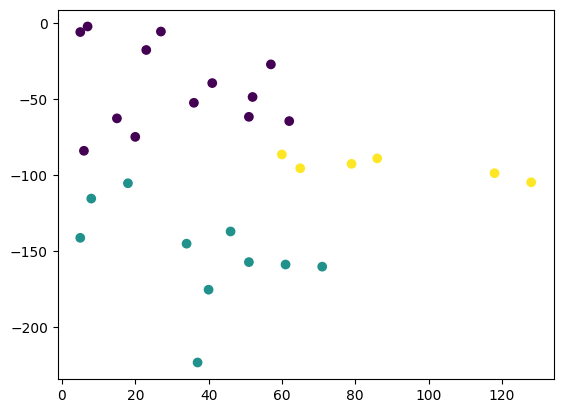

In [35]:
from sklearn.cluster import KMeans

X_columns = ['num_commits', 'AVG(diff)']
X = df[X_columns]
print(X)
kmeans = KMeans(n_clusters=3, random_state=21, n_init="auto").fit(X)
labels = kmeans.labels_
plt.scatter(df[X_columns[0]], df[X_columns[1]], c=labels)

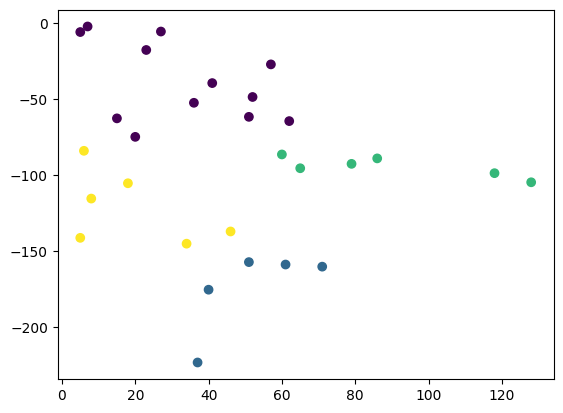

In [36]:
kmeans = KMeans(n_clusters=4, random_state=21, n_init="auto").fit(X)
labels = kmeans.labels_
plt.scatter(df[X_columns[0]], df[X_columns[1]], c=labels)

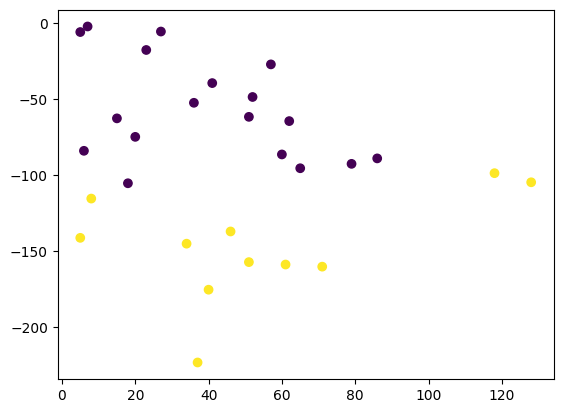

In [37]:
kmeans = KMeans(n_clusters=2, random_state=21, n_init="auto").fit(X)
labels = kmeans.labels_
plt.scatter(df[X_columns[0]], df[X_columns[1]], c=labels)

/tmp/ipykernel_15571/1157525765.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


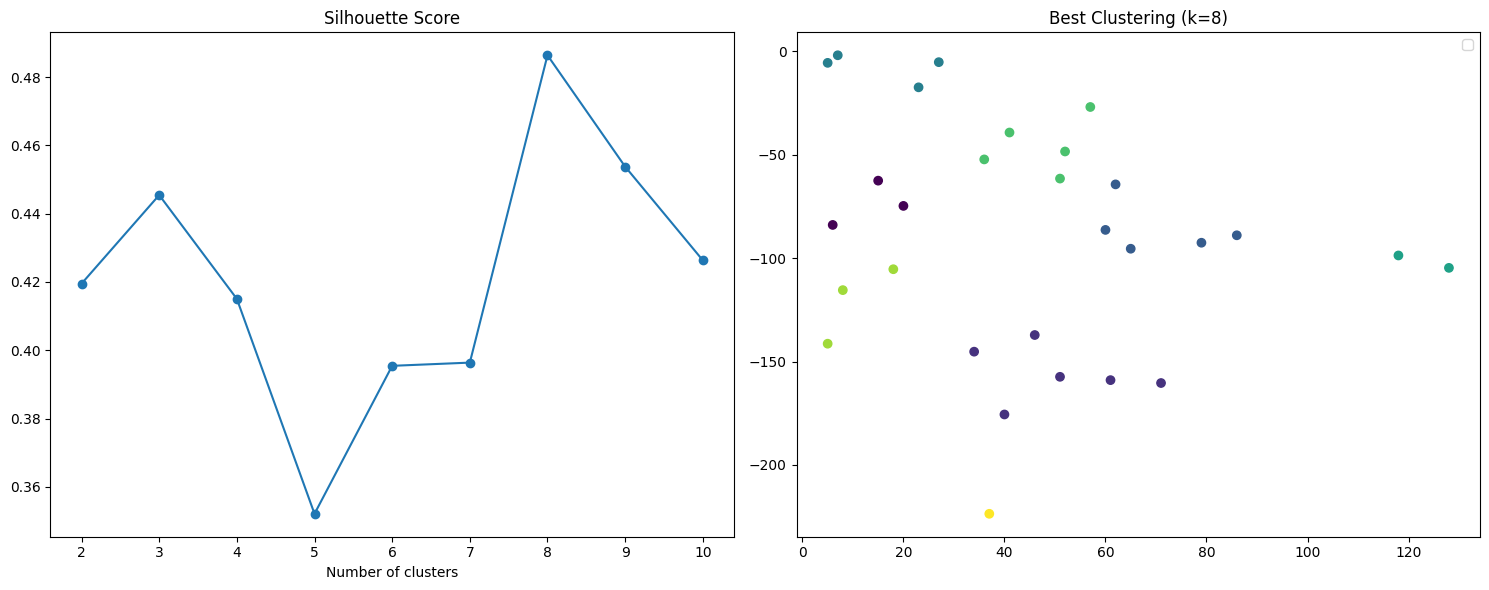

Оптимальное число кластеров: k=8


In [38]:
from sklearn.metrics import silhouette_score

def plot_cluster_analysis(X, max_k=10):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    scores = {}

    for k in range(2, max_k+1):
        kmeans = KMeans(n_clusters=k, random_state=21, n_init='auto').fit(X)
        scores[k] = silhouette_score(X, kmeans.labels_)
    
    #  # График метрик (Silhouette Score)
    ax1.plot(list(scores.keys()), list(scores.values()), marker='o')
    ax1.set_title('Silhouette Score')
    ax1.set_xlabel('Number of clusters')
    
    # График кластеров для лучшего k
    best_k = max(scores, key=scores.get)
    kmeans = KMeans(n_clusters=best_k, random_state=21, n_init='auto').fit(X)
    
    ax2.scatter(X.iloc[:, 0], X.iloc[:, 1], c=kmeans.labels_, cmap='viridis')
    ax2.set_title(f'Best Clustering (k={best_k})')
    ax2.legend()
    plt.tight_layout()
    plt.show()
    print(f"Оптимальное число кластеров: k={best_k}")
    
optimal_k = plot_cluster_analysis(X)

## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

## 5. Function

Write a function that:
1. Takes as arguments: model class of clustering, its parameters, the name of the parameter for optimization, the range of the parameter values to try.
2. Tries different values from the given parameter range and calculates the `silhouette_score` for each value from the range.
3. Finds out the best value for the parameter in the range.
4. Returns two subplots:


- - the first shows how the `silhouette_score` changes depending on the value of the parameter,
- - the second visualizes the data on a `scatter plot` using the clustering model with the best value of the parameter.